In [45]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from Bio.PDB import PDBParser
import os

In [52]:
plt.rcParams.update({
    'font.size':10,
    'axes.labelsize':10,
    'axes.titlesize':6,
    'legend.fontsize':10,
    'xtick.labelsize':10,
    'ytick.labelsize':10,
    'figure.dpi':300,
    'savefig.dpi':300,
    'axes.linewidth':0.5,
    'lines.linewidth':5,
})
plt.rcParams['axes.labelpad'] = 1     # 坐标轴标签距离
plt.rcParams['xtick.major.pad'] = 2     # X轴主刻度标签距离
plt.rcParams['ytick.major.pad'] = 2     # Y轴主刻度标签距离
plt.rcParams['axes.titlepad'] = 6      # 标题距离

In [47]:
cm = 1/2.54

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from Bio.PDB import PDBParser
import os

def read_frustration_data(dat_file):
    """
    从.dat文件中读取frustration数据
    """
    frustration_data = {}
    
    try:
        with open(dat_file, 'r') as f:
            for line in f:
                # 跳过空行和注释行
                if not line.strip() or line.startswith('#') or line.startswith('//'):
                    continue
                
                parts = line.split()
                if len(parts) >= 2:
                    # 第一列是残基序号，第二列是frustration值
                    residue_id = int(parts[0])
                    frustration_value = float(parts[1])
                    frustration_data[residue_id] = frustration_value
        
        print(f"成功从 {dat_file} 读取 {len(frustration_data)} 个残基的frustration数据")
        return frustration_data
    
    except Exception as e:
        print(f"读取文件 {dat_file} 时出错: {e}")
        return {}

def calculate_distance_to_reference(pdb_file, reference_chain, reference_resid, target_chain=None):
    """
    计算每个残基到指定参考残基的距离
    """
    
    # 创建PDB解析器
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)
    
    distances_dict = {}
    
    # 获取参考残基的CA原子坐标
    reference_coord = None
    for model in structure:
        for chain in model:
            if chain.id == reference_chain:
                for residue in chain:
                    if residue.id[1] == reference_resid:
                        if 'CA' in residue:
                            reference_coord = residue['CA'].coord
                            print(f"找到参考残基 {reference_chain}:{reference_resid}，坐标: {reference_coord}")
                            break
                if reference_coord is not None:
                    break
        if reference_coord is not None:
            break
    
    if reference_coord is None:
        print(f"错误：未找到参考残基 {reference_chain}:{reference_resid} 的CA原子")
        return distances_dict
    
    # 计算每个残基到参考残基的距离
    for model in structure:
        for chain in model:
            # 如果指定了目标链，只计算该链的残基
            if target_chain is not None and chain.id != target_chain:
                continue
                
            for residue in chain:
                if 'CA' in residue:
                    # 使用残基编号作为ID
                    residue_id = residue.id[1]
                    ca_coord = residue['CA'].coord
                    
                    # 计算到参考残基的距离
                    dist = np.linalg.norm(ca_coord - reference_coord)
                    distances_dict[residue_id] = dist
    
    print(f"成功计算了 {len(distances_dict)} 个残基到参考残基的距离")
    return distances_dict

def plot_multiple_frustration_vs_distance(pdb_file, dat_files, labels, reference_chain, reference_resid, 
                                        target_chain=None, bin_width=2.0, smoothing_sigma=1.5,
                                        colors=None, output_prefix="frustration_analysis",
                                        normalize_global=False, normalization_type="absolute",
                                        ylim=None):
    """
    主函数：读取多个frustration数据文件并在同一图中绘制
    
    新增参数:
    normalize_global: 是否对三条曲线进行整体归一化
    normalization_type: 归一化类型
        - "absolute": 除以三条曲线中绝对值的最大值
        - "positive": 找到三条曲线中的最大值，所有数据除以这个最大值
    ylim: 自定义y轴范围
    """
    
    # 检查文件是否存在
    if not os.path.exists(pdb_file):
        print(f"错误：PDB文件 {pdb_file} 不存在")
        return
    
    for dat_file in dat_files:
        if not os.path.exists(dat_file):
            print(f"错误：数据文件 {dat_file} 不存在")
            return
    
    # 计算距离（所有数据集共享相同的距离数据）
    distances_dict = calculate_distance_to_reference(pdb_file, reference_chain, reference_resid, target_chain)
    
    if not distances_dict:
        print("错误：未能计算距离")
        return
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(10.5*cm, 6*cm), dpi=300)
    plt.tick_params(axis='both', which='major', width=0.5, length=2)
    
    # 设置默认颜色
    if colors is None:
        colors = ['#E63946', '#457B9D', '#A8DADC', '#1D3557']
    
    # 存储所有曲线的数据（用于整体归一化）
    all_curves_data = []
    all_values_for_normalization = []
    
    # 处理每个frustration数据集
    for i, dat_file in enumerate(dat_files):
        # 读取frustration数据
        frustration_data = read_frustration_data(dat_file)
        
        if not frustration_data:
            print(f"错误：未能读取frustration数据 {dat_file}")
            continue
        
        # 匹配frustration数据和距离数据
        distances = []
        frustrations = []
        
        matched_count = 0
        for residue_id, frustration in frustration_data.items():
            if residue_id in distances_dict:
                distances.append(distances_dict[residue_id])
                frustrations.append(frustration)
                matched_count += 1
        
        n_total = len(distances)
        
        if n_total == 0:
            print(f"错误：没有找到匹配的残基数据 {dat_file}")
            continue
        
        print(f"成功匹配 {matched_count} 个残基的数据 {dat_file}")
        
        # 计算距离范围
        max_distance = max(distances)
        distance_bins = np.arange(0, max_distance + bin_width, bin_width)
        bin_centers = (distance_bins[:-1] + distance_bins[1:]) / 2
        
        # 计算每个距离区间内的平均frustration
        mean_frustrations = []
        
        for j in range(len(distance_bins)-1):
            mask = (np.array(distances) >= distance_bins[j]) & (np.array(distances) < distance_bins[j+1])
            if np.sum(mask) > 0:
                mean_frustrations.append(np.mean(np.array(frustrations)[mask]))
            else:
                mean_frustrations.append(np.nan)
        
        # 过滤掉没有数据的箱
        valid_indices = ~np.isnan(mean_frustrations)
        bin_centers_valid = bin_centers[valid_indices]
        mean_frustrations_valid = np.array(mean_frustrations)[valid_indices]
        
        # 应用平滑
        if smoothing_sigma > 0 and len(mean_frustrations_valid) > 1:
            mean_frustrations_smooth = gaussian_filter1d(mean_frustrations_valid, smoothing_sigma)
        else:
            mean_frustrations_smooth = mean_frustrations_valid
        
        # 存储曲线数据
        color = colors[i % len(colors)]
        label = labels[i] if i < len(labels) else f"Dataset {i+1}"
        
        # 收集所有数据用于整体归一化
        all_values_for_normalization.extend(mean_frustrations_smooth)
        all_curves_data.append({
            'bin_centers': bin_centers_valid,
            'values': mean_frustrations_smooth,
            'label': label,
            'color': color,
            'original_values': mean_frustrations_smooth.copy()  # 保存原始值
        })
    
    # 整体归一化（如果启用）
    if normalize_global and all_curves_data and all_values_for_normalization:
        print("\n=== 开始整体归一化 ===")
        all_values_for_normalization = np.array(all_values_for_normalization)
        
        if normalization_type == "absolute":
            # 找到三条曲线中绝对值的最大值
            global_max_abs = np.max(np.abs(all_values_for_normalization))
            print(f"三条曲线中绝对值的最大值: {global_max_abs:.6f}")
            
            if global_max_abs == 0:
                print("警告: 所有数据的最大绝对值为0，跳过归一化")
            else:
                # 用这个最大值归一化所有曲线
                for curve_data in all_curves_data:
                    curve_data['values'] = curve_data['values'] / global_max_abs
                
                # 验证归一化结果
                normalized_all_values = []
                for curve_data in all_curves_data:
                    normalized_all_values.extend(curve_data['values'])
                
                normalized_max_abs = np.max(np.abs(normalized_all_values))
                print(f"归一化验证: 归一化后最大绝对值 = {normalized_max_abs:.6f}")
        
        elif normalization_type == "positive":
            # 找到三条曲线中的最大值（只考虑正值）
            global_max = np.max(all_values_for_normalization)
            print(f"三条曲线中的最大值: {global_max:.6f}")
            
            if global_max == 0:
                print("警告: 所有数据的最大值为0，跳过归一化")
            else:
                # 用这个最大值归一化所有曲线
                for curve_data in all_curves_data:
                    curve_data['values'] = curve_data['values'] / global_max
                
                # 验证归一化结果
                normalized_all_values = []
                for curve_data in all_curves_data:
                    normalized_all_values.extend(curve_data['values'])
                
                normalized_max = np.max(normalized_all_values)
                print(f"归一化验证: 归一化后最大值 = {normalized_max:.6f}")
        
        else:
            print(f"警告: 未知的归一化类型 '{normalization_type}'，跳过归一化")
        
        print("=== 整体归一化完成 ===\n")
    
    # 绘制所有曲线
    for curve_data in all_curves_data:
        ax.plot(curve_data['bin_centers'], curve_data['values'], 
                linewidth=2, color=curve_data['color'], marker='o', markersize=0.6,
                label=curve_data['label'])
        
        # 打印每条曲线的统计信息（归一化后）
        if normalize_global:
            print(f"曲线 {curve_data['label']} (归一化后): 最小值 = {np.min(curve_data['values']):.4f}, 最大值 = {np.max(curve_data['values']):.4f}")
        else:
            print(f"曲线 {curve_data['label']} (未归一化): 最小值 = {np.min(curve_data['values']):.4f}, 最大值 = {np.max(curve_data['values']):.4f}")
    
    # 添加水平参考线
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.6, alpha=0.7)
    
    # 如果进行了整体归一化，添加参考线
#    if normalize_global:
#        if normalization_type == "absolute":
#            ax.axhline(y=1.0, color='red', linestyle=':', linewidth=0.4, alpha=0.3, label='Max Abs (1.0)')
#            ax.axhline(y=-1.0, color='red', linestyle=':', linewidth=0.4, alpha=0.3)
#        elif normalization_type == "positive":
#            ax.axhline(y=1.0, color='red', linestyle=':', linewidth=0.4, alpha=0.3, label='Max (1.0)')
    
    # 设置坐标轴标签
    if target_chain:
        xlabel = f'Distance (Å)'
    else:
        xlabel = f'Distance (Å)'
    
    ax.set_xlabel(xlabel)
    
    # 设置y轴标签和范围
    if normalize_global:
        if normalization_type == "positive":
            ax.set_ylabel('Normalized Frustration (Global Max)')
            if ylim is None:
                ax.set_ylim(-0.1, 1.1)
        else:
            ax.set_ylabel('Normalized Highly Frustration')
            if ylim is None:
                ax.set_ylim(-0.1, 1)
    else:
        ax.set_ylabel('Frustration Value')
        if ylim is None:
            ax.set_ylim(-0.1, 0.2)
    
    # 如果指定了y轴范围，使用它
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # 添加图例
    ax.legend(fontsize=5, loc=4)
    
    # 移除上、右边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 保存图形
#    output_file = f"{output_prefix}.png"
#    plt.savefig(output_file, dpi=300, bbox_inches='tight')
#    print(f"图形已保存为: {output_file}")
    
    # 显示图形
    # plt.show()
    
    return fig

找到参考残基 B:230，坐标: [48.093 49.666 32.857]
成功计算了 245 个残基到参考残基的距离
成功从 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/pdbresult 读取 245 个残基的frustration数据
成功匹配 245 个残基的数据 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/pdbresult
成功从 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/mdresult 读取 245 个残基的frustration数据
成功匹配 245 个残基的数据 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/mdresult
成功从 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/result 读取 245 个残基的frustration数据
成功匹配 245 个残基的数据 /home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/result

=== 开始整体归一化 ===
三条曲线中绝对值的最大值: 0.395688
归一化验证: 归一化后最大绝对值 = 1.000000
=== 整体归一化完成 ===

曲线 PDB (归一化后): 最小值 = 0.1654, 最大值 = 0.4064
曲线 MD (归一化后): 最小值 = 0.1604, 最大值 = 1.0000
曲线 MD-PDB (归一化后): 最小值 = -0.0427, 最大值 = 0.6301


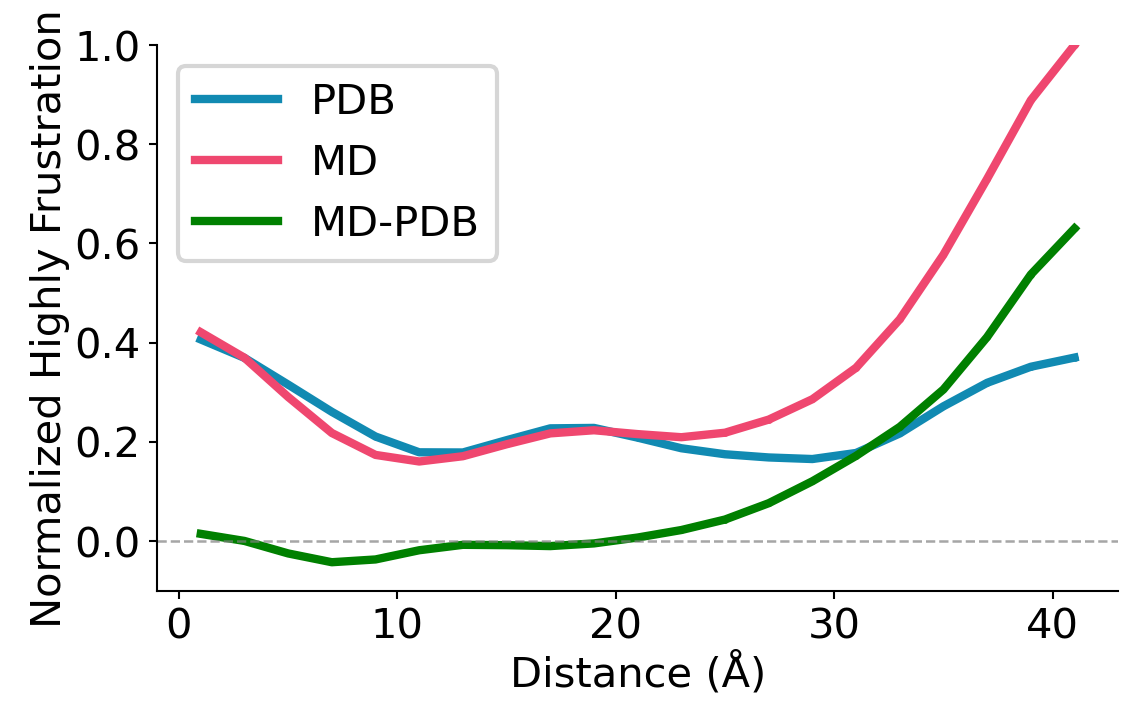

In [65]:
# ==================== 在这里设置您的文件路径和参数 ====================

if __name__ == "__main__":
    # 1. 设置PDB文件路径
    pdb_file = "/home/teliu/work/nanobody/newgroup/2p4x/pdb/2p42.pdb"
    
    # 2. 设置.dat文件路径列表
    dat_files = [
        "/home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/pdbresult",
        "/home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/mdresult",
        "/home/teliu/work/nanobody/newgroup/2p4x/frustration/md/300/result/result"
    ]
    
    # 3. 设置每个数据集的标签
    labels = ["PDB", "MD", "MD-PDB"]
    
    # 4. 设置参考残基（结合界面残基）
    reference_chain = 'B'
    reference_resid = 230
    
    # 5. 设置目标链（如果为None则使用所有链）
    target_chain = None
    
    # 6. 归一化选项（新增参数）
    normalize_global = True  # 是否进行整体归一化
    normalization_type = "absolute"  # 归一化类型: "absolute"或"positive"
    
    # 7. 可选参数调整
    bin_width = 2.0
    smoothing_sigma = 1.5
    colors = ['#118AB2', "#EF476F", 'green']  # 可选：为每个数据集指定颜色
    output_prefix = "multiple_frustration_analysis_global_normalized"
    
    # 8. 自定义y轴范围（如果需要）
    # ylim = [-1.2, 1.2]  # 归一化到[-1, 1]时使用
    # ylim = [-0.1, 1.1]  # 归一化到[0, 1]时使用
    
    # 运行分析
    plot_multiple_frustration_vs_distance(
        pdb_file=pdb_file,
        dat_files=dat_files,
        labels=labels,
        reference_chain=reference_chain,
        reference_resid=reference_resid,
        target_chain=target_chain,
        bin_width=bin_width,
        smoothing_sigma=smoothing_sigma,
        colors=colors,
        output_prefix=output_prefix,
        normalize_global=normalize_global,
        normalization_type=normalization_type,
        # ylim=ylim  # 取消注释以使用自定义y轴范围
    )
    plt.legend(loc=2,fontsize=10)
    plt.savefig('/home/teliu/work/nanobody/image/draft/fig5/2p4x-fru-global-normalized.png', bbox_inches='tight', transparent=True)

找到参考残基 B:299，坐标: [55.306 52.35  33.218]
成功计算了 324 个残基到参考残基的距离
成功从 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/pdbresult 读取 324 个残基的frustration数据
成功匹配 324 个残基的数据 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/pdbresult
成功从 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/mdresult 读取 324 个残基的frustration数据
成功匹配 324 个残基的数据 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/mdresult
成功从 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/result 读取 324 个残基的frustration数据
成功匹配 324 个残基的数据 /home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/result

=== 开始整体归一化 ===
三条曲线中绝对值的最大值: 0.114574
归一化验证: 归一化后最大绝对值 = 1.000000
=== 整体归一化完成 ===

曲线 PDB (归一化后): 最小值 = 0.1639, 最大值 = 0.9850
曲线 MD (归一化后): 最小值 = 0.5026, 最大值 = 1.0000
曲线 Difference (归一化后): 最小值 = -0.0423, 最大值 = 0.3455


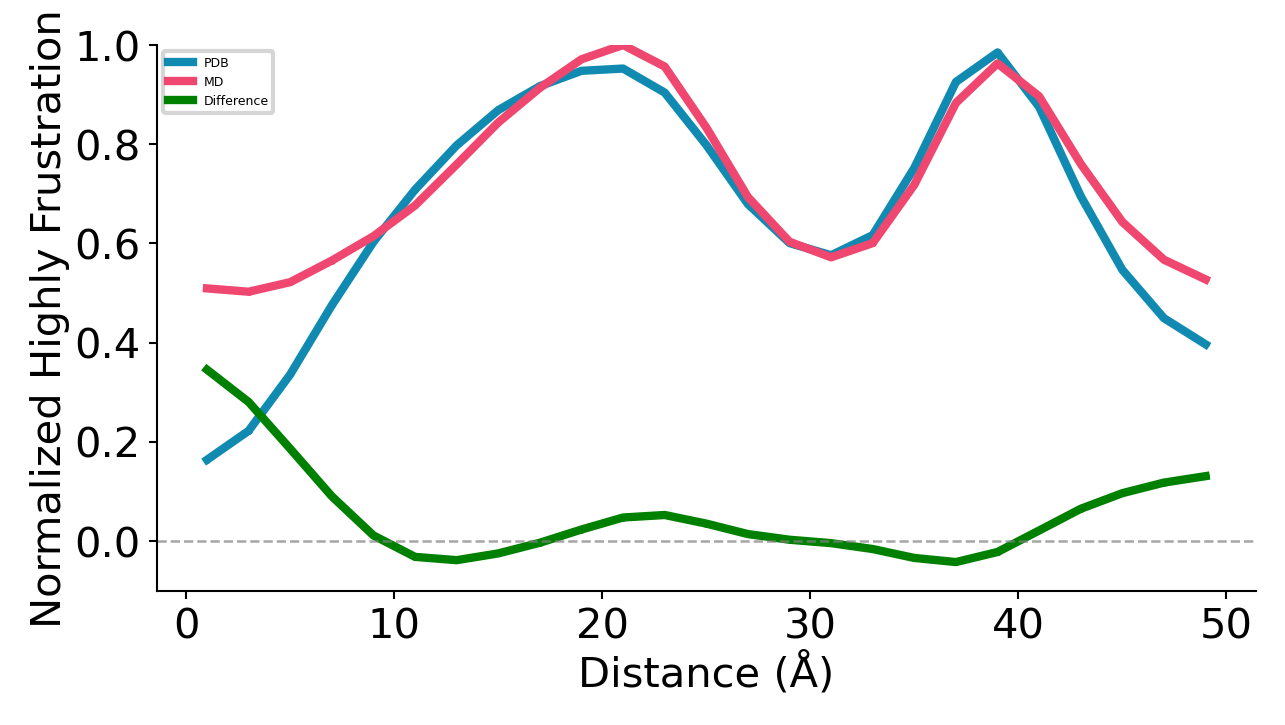

In [62]:
if __name__ == "__main__":
    # 1. 设置PDB文件路径
    pdb_file = "/home/teliu/work/nanobody/newgroup/pnas/md/com/pdb/7z1a.pdb"
    
    # 2. 设置.dat文件路径列表
    dat_files = [
        "/home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/pdbresult",
        "/home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/mdresult",
        "/home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/md/300/result/result"
    ]
    
    # 3. 设置每个数据集的标签
    labels = ["PDB", "MD", "Difference"]
    
    # 4. 设置参考残基（结合界面残基）
    reference_chain = 'B'
    reference_resid = 299
    
    # 5. 设置目标链（如果为None则使用所有链）
    target_chain = None
    
    # 6. 归一化选项（新增参数）
    normalize_global = True  # 是否进行整体归一化
    normalization_type = "absolute"  # 归一化类型: "absolute"或"positive"
    
    # 7. 可选参数调整
    bin_width = 2.0
    smoothing_sigma = 1.5
    colors = ['#118AB2', "#EF476F", 'green']  # 可选：为每个数据集指定颜色
    output_prefix = "multiple_frustration_analysis_global_normalized"
    
    # 8. 自定义y轴范围（如果需要）
    # ylim = [-1.2, 1.2]  # 归一化到[-1, 1]时使用
    # ylim = [-0.1, 1.1]  # 归一化到[0, 1]时使用
    
    # 运行分析
    plot_multiple_frustration_vs_distance(
        pdb_file=pdb_file,
        dat_files=dat_files,
        labels=labels,
        reference_chain=reference_chain,
        reference_resid=reference_resid,
        target_chain=target_chain,
        bin_width=bin_width,
        smoothing_sigma=smoothing_sigma,
        colors=colors,
        output_prefix=output_prefix,
        normalize_global=normalize_global,
        normalization_type=normalization_type,
        # ylim=ylim  # 取消注释以使用自定义y轴范围
    )
    plt.legend(loc=2,fontsize=3)
    plt.savefig('/home/teliu/work/nanobody/image/draft/fig5/7z1x-fru-global-normalized.png', bbox_inches='tight', transparent=True)

In [57]:
data2p42=np.loadtxt('/home/teliu/work/nanobody/newgroup/2p4x/frustration/pdb/2p42/result/2p42.done/FrustrationData/temp.dat',comments="#")

<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:16: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1512374/2061503177.py:16: SyntaxWarning: invalid escape sequence '\A'
  ax1.set_ylabel('Local Frustration Destiny(5$\AA$ Sphere)', fontsize=5)


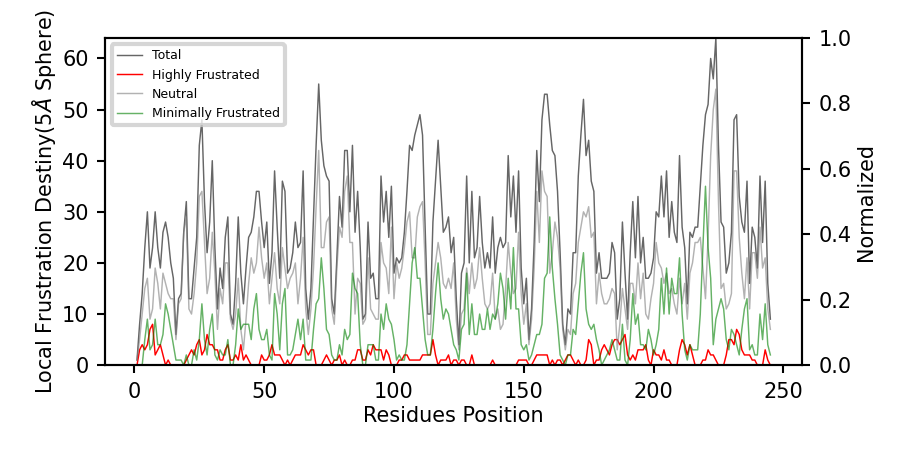

In [67]:
plt.figure(figsize=(3,1.5), dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)

# 创建第一个y轴
ax1 = plt.gca()

# 绘制所有数据（都在第一个y轴上）
line1, = ax1.plot(data2p42[:,0], data2p42[:,1], color='black', linewidth=0.35, label='Total', alpha=0.6)
line2, = ax1.plot(data2p42[:,0], data2p42[:,2], color='red', linewidth=0.35, label='Highly Frustrated')
line3, = ax1.plot(data2p42[:,0], data2p42[:,3], color='gray', linewidth=0.35, label='Neutral', alpha=0.6)
line4, = ax1.plot(data2p42[:,0], data2p42[:,4], color='green', linewidth=0.35, label='Minimally Frustrated', alpha=0.6)

# 设置第一个y轴的范围和标签
ax1.set_ylim(0, 64)
ax1.set_xlabel('Residues Position', fontsize=5)
ax1.set_ylabel('Local Frustration Destiny(5$\AA$ Sphere)', fontsize=5)

# 创建第二个y轴（与第一个y轴共享x轴）
ax2 = ax1.twinx()

# 设置第二个y轴的范围，使其与第一个y轴成比例
ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', which='major', width=0.5, length=2)
# 为了美观，可以设置第二个y轴的颜色与第一个不同
#ax2.spines['right'].set_color('blue')
#ax2.tick_params(axis='y', colors='blue')

# 添加第二个y轴的标签
ax2.set_ylabel('Normalized', fontsize=5, color='black')

# 图例
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc=2, fontsize=3)

# 调整图形布局
plt.tight_layout()

plt.savefig('/home/teliu/work/nanobody/image/draft/fig5/2p42-pdb-fru.png', bbox_inches='tight', transparent=True)

In [62]:
data7z1a=np.loadtxt('/home/teliu/work/nanobody/newgroup/pnas/md/com/frustration/pdb/7z1a/result/7z1a.done/FrustrationData/temp.dat',comments="#")

<>:16: SyntaxWarning: invalid escape sequence '\A'
<>:16: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1512374/107683763.py:16: SyntaxWarning: invalid escape sequence '\A'
  ax1.set_ylabel('Local Frustration Destiny(5$\AA$ Sphere)', fontsize=5)


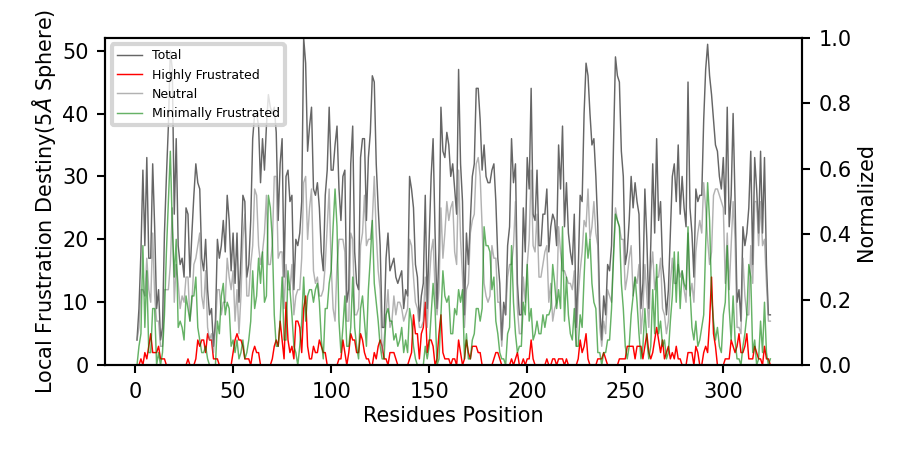

In [68]:
plt.figure(figsize=(3,1.5), dpi=300)
plt.tick_params(axis='both', which='major', width=0.5, length=2)

# 创建第一个y轴
ax1 = plt.gca()

# 绘制所有数据（都在第一个y轴上）
line1, = ax1.plot(data7z1a[:,0], data7z1a[:,1], color='black', linewidth=0.35, label='Total', alpha=0.6)
line2, = ax1.plot(data7z1a[:,0], data7z1a[:,2], color='red', linewidth=0.35, label='Highly Frustrated')
line3, = ax1.plot(data7z1a[:,0], data7z1a[:,3], color='gray', linewidth=0.35, label='Neutral', alpha=0.6)
line4, = ax1.plot(data7z1a[:,0], data7z1a[:,4], color='green', linewidth=0.35, label='Minimally Frustrated', alpha=0.6)

# 设置第一个y轴的范围和标签
ax1.set_ylim(0, 52)
ax1.set_xlabel('Residues Position', fontsize=5)
ax1.set_ylabel('Local Frustration Destiny(5$\AA$ Sphere)', fontsize=5)

# 创建第二个y轴（与第一个y轴共享x轴）
ax2 = ax1.twinx()

# 设置第二个y轴的范围，使其与第一个y轴成比例
ax2.set_ylim(0, 1)
ax2.tick_params(axis='both', which='major', width=0.5, length=2)
# 为了美观，可以设置第二个y轴的颜色与第一个不同
#ax2.spines['right'].set_color('blue')
#ax2.tick_params(axis='y', colors='blue')

# 添加第二个y轴的标签
ax2.set_ylabel('Normalized', fontsize=5, color='black')

# 图例
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc=2, fontsize=3)

# 调整图形布局
plt.tight_layout()

plt.savefig('/home/teliu/work/nanobody/image/draft/fig5/7z1a-pdb-fru.png', bbox_inches='tight', transparent=True)